# Hybrid Test Case

## PID Controller - Integrator Reset

- Integrator of the PID controller is reset if a contact flag is set
- Discrete Update with $dt = 0$ s
- Requires Euler Solver for FMU
- CVode solver cannot handle discrete event (discrete change of continuous signal)

### CVODE

- Soler for differential-algebraic equations
- Methods used in CVODE are of variable-order, variable-setp multistep methods based on formulas of the form

$$
\sum_{i=0}^{K_1} \alpha_{n,i} y^{n-i} + h_n \sum_{i=0}^{K_2} \beta_{n,i} \dot{y}^{n-i} = 0
$$

where:
- $y^n$ are the computed approximations to $y(t_n)$
- $h_n = t_n - t_{n-1}$ is the step size


- There are two multistep methods available:
    - Adams-Moulton methods for non-stiff problems charcterized by $K_1 = 1$ and $K_2 = q -1$ where $q$ varies between 1 and 12
    - For stiff problems, CVODE includes Backward Differentiation Formulas (BDF) in the fixed-leading coefficient (FLC) form where $K_1 = q$ and $K_2 = 0$ with $q$ varying between 1 and 5
- The coefficients are uniquely determined by the method type, order, and the recent history of steo sizes, and normalization $\alpha_{n,0} = 1$.

- CVODE maintains an internal state vectot that includes:
    - Current solution values
    - Derivative approximations
    - Step size history
    - Error estimated
    - Jacobian information

- When `reinit(y, 0)`is called in the Modelica integrator during a zero-time event `dt=0`, the integrator's state variable was reset, but CVODE's internal state was not properly synchronized
- The integrator values appeared to reset, but CVODE continued to use its previous state information, leading to inconsistencies in the simulation results

### Euler
- The Euler method is a simple explicit fixed-step method which does not maintain an internal state like CVODE
- When the integrator's state variable is reset using `reinit(y, 0)`, the Euler method immediately reflects this change in its computations
- This direct approach ensures that the integrator's state is always in sync with the simulation, avoiding the inconsistencies observed with CVODE during zero-time events

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

In [9]:
from OMPython import ModelicaSystem
from shutil import move

pkg_file = Path.cwd().parent / 'Modelica/ControlledPendulum/package.mo'
model_name = 'ControlledPendulum.PID_Continuous'
#solver = "euler"
solver = "cvode"
model = ModelicaSystem(str(pkg_file), model_name, commandLineOptions=f"--fmiFlags=s:{solver}")
model.buildModel()

fmu_path = model.convertMo2Fmu(fmuType='cs')

dest_path = Path.cwd().parent / 'FMUs/PID_Continuous.fmu'
move(fmu_path, dest_path)

print(f"FMU saved to: {dest_path}")


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


FMU saved to: /home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PID_Continuous.fmu


In [6]:
pid = FMUComponent(fmu_path=dest_path, name='pid')
t = 0.0
pid.initialize(t0=t)

print("\n\n=== Input Specifications ===")
for name, spec in pid.input_specs.items():
    print(f"Name: {name}")
    print(f"  Type: {spec.type}")
    print(f"  Causality: {spec.direction}")
    print(f"  Unit: {spec.unit}")
    print(f"  Description: {spec.description}")

print("\n=== Output Specifications ===")
for name, spec in pid.output_specs.items():
    print(f"Name: {name}")
    print(f"  Type: {spec.type}")
    print(f"  Causality: {spec.direction}")
    print(f"  Unit: {spec.unit}")
    print(f"  Description: {spec.description}")

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


=== Input Specifications ===
Name: ref
  Type: PortType.REAL
  Causali

In [7]:
pid.initialize(t0=0.0)
t = 0
dt = 0.1

vars = pid._md_vars
ref_vr = vars['ref'].valueReference
y_vr = vars['y'].valueReference
reset_vr = vars['resetI'].valueReference
i_out_vr = vars['I_out'].valueReference

fmu = pid._instance

# Initial setup
ref = 1.0
y = 0.0
fmu.setReal([ref_vr, y_vr], [ref, y])
fmu.doStep(t, 0)
out = fmu.getReal([ref_vr, y_vr, i_out_vr])
print(f"Initial: {out}")

# First time step
fmu.doStep(t, dt)
t += dt
print(f"t: {t} s")
out = fmu.getReal([ref_vr, y_vr, i_out_vr])
print(f"Before reset: {out}")

# Reset the integrator
fmu.setBoolean([reset_vr], [True])
fmu.doStep(t, 0)
print(f"Reset at t = {t} s")
out = fmu.getReal([ref_vr, y_vr, i_out_vr])
print(f"After reset (with reset=True): {out}")

# ✅ CRITICAL: Clear reset signal!
fmu.setBoolean([reset_vr], [False])
fmu.doStep(t, 0)  # Optional: stabilization step
print(f"After clearing reset: {fmu.getReal([i_out_vr])[0]}")

# Continue integration
fmu.doStep(t, dt)
t += dt
print(f"t: {t} s")
out = fmu.getReal([ref_vr, y_vr, i_out_vr])
print(f"After next step: {out}")

Initial: [1.0, 0.0, 0.0]
t: 0.1 s
Before reset: [1.0, 0.0, 1.9999999999999998]
Reset at t = 0.1 s
After reset (with reset=True): [1.0, 0.0, 0.0]
After clearing reset: 0.0
t: 0.2 s
After next step: [1.0, 0.0, 4.000000000000001]
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE max

In [8]:
pid = FMUComponent(fmu_path=dest_path, name='pid')
t = 0.0
pid.initialize(t0=t)

ref = 1.0
y = 0.0
inputs = {'ref': ref, 'y': y, 'resetI': False}
pid.set_inputs(inputs)

dt = 0.1

t = 0.0
t_values = [0]
u_values = [0]
I_out_values = [0]
for i in range(10):
    pid.do_step(t, dt)
    t += dt
    outputs = pid.get_outputs()
    print(f"t: {t:.1f} s, outputs: {outputs}")
    t_values.append(t)
    I_out_values.append(outputs['I_out'])
    u_values.append(outputs['u'])
    if i == 4 :
        pid.set_inputs({'resetI': True})
        pid.do_step(t, 0)  # Apply reset immediately
        pid.set_inputs({'resetI': False})  # Clear reset
        print(f"Reset integrator at t: {t:.1f} s")
        print(f"Outputs after reset: {pid.get_outputs()}")
        t_values.append(t)
        I_out_values.append(pid.get_outputs()['I_out'])
        u_values.append(pid.get_outputs()['u'])

t: 0.1 s, outputs: {'I_out': 1.9999999999999998, 'u': 1.0}
t: 0.2 s, outputs: {'I_out': 4.000000000000001, 'u': 1.0}
t: 0.3 s, outputs: {'I_out': 6.0, 'u': 1.0}
t: 0.4 s, outputs: {'I_out': 8.000000000000002, 'u': 1.0}
t: 0.5 s, outputs: {'I_out': 9.999999999999998, 'u': 1.0}
Reset integrator at t: 0.5 s
Outputs after reset: {'I_out': 0.0, 'u': 1.0}
t: 0.6 s, outputs: {'I_out': 11.999999999999995, 'u': 1.0}
t: 0.7 s, outputs: {'I_out': 14.000000000000025, 'u': 1.0}
t: 0.8 s, outputs: {'I_out': 16.000000000000032, 'u': 1.0}
t: 0.9 s, outputs: {'I_out': 18.00000000000003, 'u': 1.0}
t: 1.0 s, outputs: {'I_out': 20.00000000000003, 'u': 1.0}
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear s

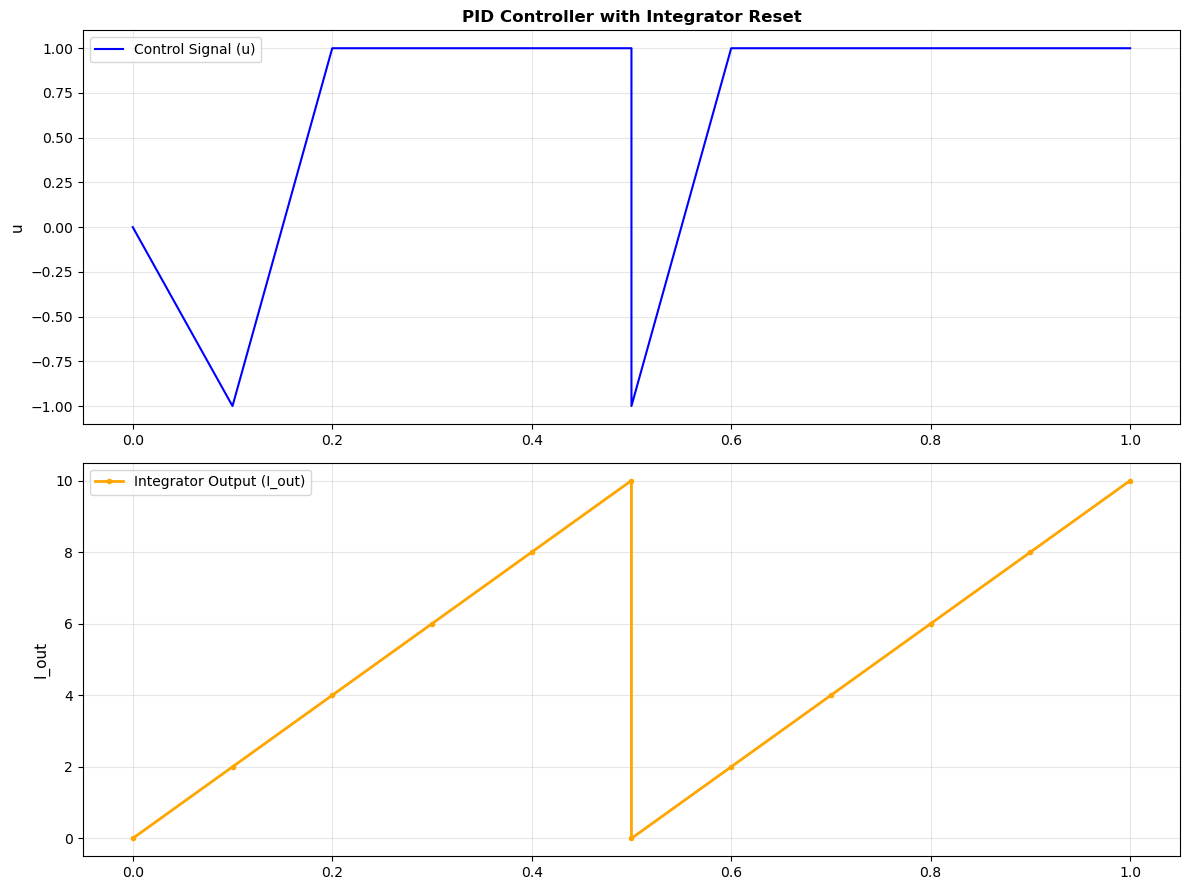


Summary:
  Total time steps: 12
  Final integrator value: 10.0000


In [7]:
# Plot results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))

plt.subplot(2, 1, 1)
plt.plot(t_values, u_values, 'b-', linewidth=1.5, label='Control Signal (u)')
plt.ylabel('u', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.title('PID Controller with Integrator Reset', fontsize=12, fontweight='bold')

plt.subplot(2, 1, 2)
plt.plot(t_values, I_out_values, 'orange', linewidth=2, label='Integrator Output (I_out)', marker='o', markersize=3)
plt.ylabel('I_out', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*50}")
print(f"Summary:")
print(f"  Total time steps: {len(t_values)}")
print(f"  Final integrator value: {I_out_values[-1]:.4f}")
print(f"{'='*50}")

In [36]:
fmu.reset()
fmu.instantiate()
fmu.setupExperiment(startTime=0.0)
fmu.enterInitializationMode()
fmu.exitInitializationMode()
state = fmu.getFMUState()


In [37]:
fmu.setReal([ref_vr, y_vr], [ref, y])
fmu.getReal([i_out_vr])

[0.0]

In [38]:
fmu.doStep(0.0, 0.1)

In [39]:
fmu.getReal([i_out_vr])

[2.0]

In [40]:
fmu.setFMUstate(state)
fmu.doStep(0.0, 0.1)
fmu.getReal([i_out_vr])

LOG_ASSERT        | debug   | division by zero at time 0, (a=0) / (b=0), where divisor b expression is: D.T
LOG_ASSERT        | debug   | division by zero at time 0, (a=0) / (b=0), where divisor b expression is: D.T


FMICallException: fmi2DoStep failed with status 3 (error).